# Détection de Fraude Bancaire (Credit Card Fraud) avec un MLP

Utilisation d'Optuna + PyTorch sur le dataset réel Credit Card Fraud (transactions bancaires anonymisées).
Focus sur la gestion du déséquilibre de classes et les métriques adaptées: PR-AUC, Recall, F1, ROC-AUC.


In [21]:
import os
import sys
import time
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    classification_report,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

try:
    import optuna
except ImportError:
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "optuna"])
    import optuna

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.figsize": (10, 6), "axes.titlesize": 14, "axes.labelsize": 12})

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")


Device: cpu


Loaded from: https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv
Shape: (284807, 31)
Fraud rate: 0.1727%
Class counts:
 Class
0    284315
1       492
Name: count, dtype: int64

Data preview:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0



Descriptive statistics:


,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.168375e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.416908e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.074095e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,9.604066e-16,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.487313e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.556467e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.213481e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.406331e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995



La colonne Time sera retirée pour simplifier la modélisation.


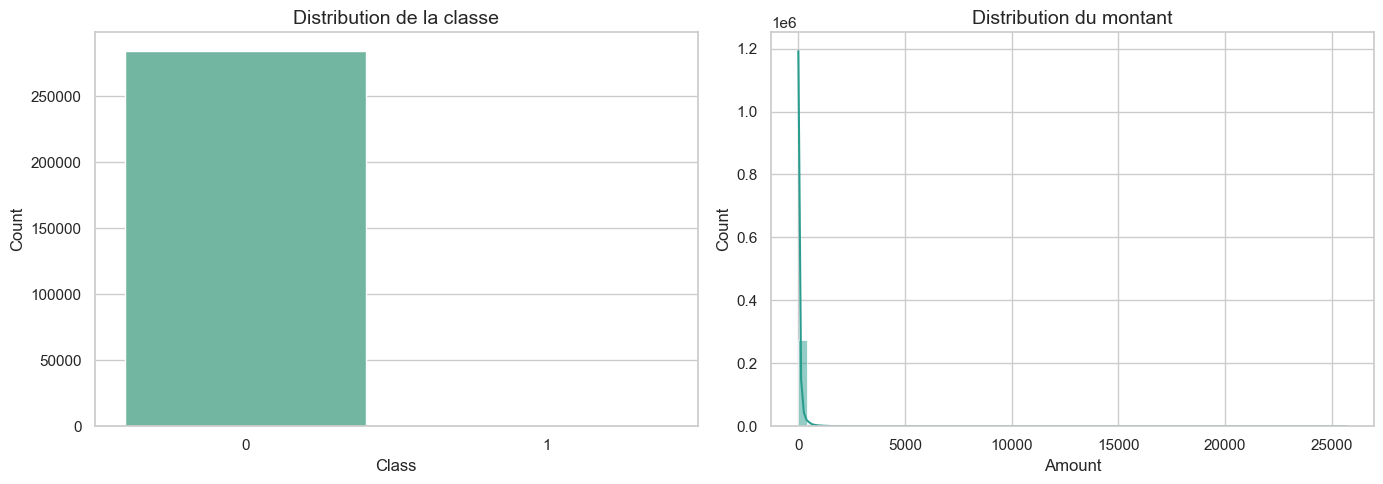

In [22]:
credit_card_url = "https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv"
local_candidate = Path("..") / "002_Regression_Logistique" / "creditcard.csv"

if local_candidate.exists():
    df = pd.read_csv(local_candidate)
    source_name = str(local_candidate)
else:
    df = pd.read_csv(credit_card_url)
    source_name = credit_card_url

if "Class" not in df.columns:
    raise ValueError(f"Expected a fraud dataset with a 'Class' column, got columns: {list(df.columns)}")

print("Loaded from:", source_name)
print("Shape:", df.shape)
fraud_rate = df["Class"].mean()
print(f"Fraud rate: {fraud_rate:.4%}")
print("Class counts:\n", df["Class"].value_counts())
print("\nData preview:")
display(df.head())

print("\nDescriptive statistics:")
display(df.describe().T)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(data=df, x="Class", hue="Class", ax=axes[0], palette="Set2", legend=False)
axes[0].set_title("Distribution de la classe")
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Count")

sns.histplot(df["Amount"], bins=60, kde=True, ax=axes[1], color="#2a9d8f")
axes[1].set_title("Distribution du montant")
axes[1].set_xlabel("Amount")
axes[1].set_ylabel("Count")
plt.tight_layout()

if "Time" in df.columns:
    print("\nLa colonne Time sera retirée pour simplifier la modélisation.")


In [27]:
target_column = "Class"
feature_columns = [col for col in df.columns if col != target_column]
if "Time" in feature_columns:
    feature_columns.remove("Time")

X = df[feature_columns].copy()
y = df[target_column].astype(np.float32).to_numpy()

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=0.15,
    random_state=SEED,
    stratify=y,
)

relative_val_size = 0.15 / 0.85
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=relative_val_size,
    random_state=SEED,
    stratify=y_train_val,
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train_scaled.shape, "| Fraud rate:", y_train.mean())
print("Val shape:  ", X_val_scaled.shape, "| Fraud rate:", y_val.mean())
print("Test shape: ", X_test_scaled.shape, "| Fraud rate:", y_test.mean())


Train shape: (199364, 29) | Fraud rate: 0.0017254871
Val shape:   (42721, 29) | Fraud rate: 0.0017321692
Test shape:  (42722, 29) | Fraud rate: 0.0017321287


In [ ]:
class FraudMLP(nn.Module):
    def __init__(self, input_dim, hidden_dims=(256, 128), dropout=0.25):
        super().__init__()
        layers = []
        in_dim = input_dim
        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(in_dim, hidden_dim))
            layers.append(nn.BatchNorm1d(hidden_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            in_dim = hidden_dim
        layers.append(nn.Linear(in_dim, 1))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x).squeeze(-1)


def make_dataloader(X_array, y_array, batch_size=512, shuffle=False):
    X_tensor = torch.tensor(X_array, dtype=torch.float32)
    y_tensor = torch.tensor(y_array, dtype=torch.float32)
    dataset = TensorDataset(X_tensor, y_tensor)
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)


def get_pos_weight(y_array, multiplier=1.0):
    positive = float(np.sum(y_array == 1))
    negative = float(np.sum(y_array == 0))
    base_weight = negative / max(positive, 1.0)
    return torch.tensor(base_weight * multiplier, dtype=torch.float32, device=device)


def predict_proba(model, loader):
    model.eval()
    probabilities = []
    targets = []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            logits = model(X_batch)
            probabilities.extend(torch.sigmoid(logits).cpu().numpy())
            targets.extend(y_batch.numpy())
    return np.asarray(targets), np.asarray(probabilities)


def evaluate_model(model, loader, loss_fn):
    y_true, y_prob = predict_proba(model, loader)
    y_pred = (y_prob >= 0.5).astype(int)
    metrics = {
        "loss": None,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else np.nan,
        "pr_auc": average_precision_score(y_true, y_prob),
    }

    losses = []
    model.eval()
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            logits = model(X_batch)
            losses.append(loss_fn(logits, y_batch).item())
    metrics["loss"] = float(np.mean(losses))
    return metrics, y_true, y_prob


def train_model(model, train_loader, val_loader, loss_fn, optimizer, max_epochs=50, patience=8):
    best_state = None
    best_score = -np.inf
    best_epoch = 0
    history = []
    patience_counter = 0

    for epoch in range(1, max_epochs + 1):
        model.train()
        train_losses = []
        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()
            logits = model(X_batch)
            loss = loss_fn(logits, y_batch)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optimizer.step()
            train_losses.append(loss.item())

        val_metrics, _, _ = evaluate_model(model, val_loader, loss_fn)
        train_loss = float(np.mean(train_losses))
        history.append({"epoch": epoch, "train_loss": train_loss, **val_metrics})

        print(
            f"Epoch {epoch:03d} | train_loss={train_loss:.4f} | val_loss={val_metrics['loss']:.4f} | val_pr_auc={val_metrics['pr_auc']:.4f}"
        )

        if val_metrics["pr_auc"] > best_score:
            best_score = val_metrics["pr_auc"]
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            best_epoch = epoch
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch}. Best epoch: {best_epoch}.")
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    return model, pd.DataFrame(history), best_epoch, best_score


In [26]:
input_dim = X_train_scaled.shape[1]

def objective(trial):
    hidden_choice = trial.suggest_categorical(
        "hidden_dims",
        ["128,64", "256,128", "256,128,64", "512,256"],
    )
    hidden_dims = tuple(int(value) for value in hidden_choice.split(","))
    dropout = trial.suggest_float("dropout", 0.10, 0.50)
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 3e-3, log=True)
    batch_size = trial.suggest_categorical("batch_size", [256, 512, 1024])
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True)
    pos_weight_multiplier = trial.suggest_float("pos_weight_multiplier", 0.75, 1.50)

    train_loader = make_dataloader(X_train_scaled, y_train, batch_size=batch_size, shuffle=True)
    val_loader = make_dataloader(X_val_scaled, y_val, batch_size=2048, shuffle=False)

    model = FraudMLP(input_dim=input_dim, hidden_dims=hidden_dims, dropout=dropout).to(device)
    loss_fn = nn.BCEWithLogitsLoss(pos_weight=get_pos_weight(y_train, multiplier=pos_weight_multiplier))
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

    model, history, _, best_score = train_model(
        model,
        train_loader,
        val_loader,
        loss_fn,
        optimizer,
        max_epochs=20,
        patience=4,
    )

    trial.set_user_attr("best_epoch", int(history.loc[history["pr_auc"].idxmax(), "epoch"]))
    return best_score


study_name = "credit_card_fraud_mlp"
storage = "sqlite:///fraud_optuna.db"
study = optuna.create_study(
    direction="maximize",
    study_name=study_name,
    storage=storage,
    load_if_exists=True,
)

n_trials = 20
start_time = time.time()
current_trials = len(study.trials)
remaining_trials = max(n_trials - current_trials, 0)
print(f"Reprendre à partir du trial {current_trials}...")
if remaining_trials > 0:
    study.optimize(objective, n_trials=remaining_trials, show_progress_bar=False)
else:
    print("Tous les trials demandés ont déjà été exécutés.")
optuna_duration = time.time() - start_time

print("Best PR-AUC:", study.best_value)
print("Best params:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")
print(f"Total trials completed: {len(study.trials)}/{n_trials}")
print(f"Optuna duration: {optuna_duration / 60:.2f} minutes")


[I 2026-05-11 19:59:25,717] Using an existing study with name 'credit_card_fraud_mlp' instead of creating a new one.


Reprendre à partir du trial 20...
Tous les trials demandés ont déjà été exécutés.
Best PR-AUC: 0.8554694344007866
Best params:
  hidden_dims: 256,128
  dropout: 0.1612033366289594
  learning_rate: 0.000867237773900139
  batch_size: 512
  weight_decay: 3.84461433901432e-06
  pos_weight_multiplier: 1.4824591369880074
Total trials completed: 20/20
Optuna duration: 0.00 minutes


In [ ]:
best_hidden_dims = tuple(int(value) for value in study.best_params["hidden_dims"].split(","))
final_dropout = study.best_params["dropout"]
final_lr = study.best_params["learning_rate"]
final_batch_size = study.best_params["batch_size"]
final_weight_decay = study.best_params["weight_decay"]
final_pos_weight_multiplier = study.best_params["pos_weight_multiplier"]

X_train_full = np.vstack([X_train_scaled, X_val_scaled])
y_train_full = np.concatenate([y_train, y_val])
train_full_loader = make_dataloader(X_train_full, y_train_full, batch_size=final_batch_size, shuffle=True)
final_val_loader = make_dataloader(X_val_scaled, y_val, batch_size=2048, shuffle=False)

final_model = FraudMLP(input_dim=input_dim, hidden_dims=best_hidden_dims, dropout=final_dropout).to(device)
final_loss_fn = nn.BCEWithLogitsLoss(pos_weight=get_pos_weight(y_train_full, multiplier=final_pos_weight_multiplier))
final_optimizer = torch.optim.Adam(final_model.parameters(), lr=final_lr, weight_decay=final_weight_decay)

print("Training final model with best hyperparameters...")
final_start = time.time()
final_model, final_history, final_best_epoch, final_best_score = train_model(
    final_model,
    train_full_loader,
    final_val_loader,
    final_loss_fn,
    final_optimizer,
    max_epochs=40,
    patience=8,
)
final_duration = time.time() - final_start

print(f"Final best validation PR-AUC: {final_best_score:.4f}")
print(f"Best epoch: {final_best_epoch}")
print(f"Training duration: {final_duration / 60:.2f} minutes")


Training final model with best hyperparameters...
Epoch 001 | train_loss=0.5876 | val_loss=0.2694 | val_pr_auc=0.7699
Epoch 002 | train_loss=0.4381 | val_loss=0.2181 | val_pr_auc=0.7874
Epoch 003 | train_loss=0.3102 | val_loss=0.1575 | val_pr_auc=0.7914
Epoch 004 | train_loss=0.2399 | val_loss=0.1145 | val_pr_auc=0.8048
Epoch 005 | train_loss=0.2207 | val_loss=0.0993 | val_pr_auc=0.7940
Epoch 006 | train_loss=0.1836 | val_loss=0.1120 | val_pr_auc=0.8246
Epoch 007 | train_loss=0.1655 | val_loss=0.0728 | val_pr_auc=0.8105
Epoch 008 | train_loss=0.1557 | val_loss=0.0496 | val_pr_auc=0.8278
Epoch 009 | train_loss=0.1198 | val_loss=0.0499 | val_pr_auc=0.8318
Epoch 010 | train_loss=0.1090 | val_loss=0.0432 | val_pr_auc=0.8377
Epoch 011 | train_loss=0.0859 | val_loss=0.0501 | val_pr_auc=0.8327
Epoch 012 | train_loss=0.0879 | val_loss=0.0340 | val_pr_auc=0.8660
Epoch 013 | train_loss=0.1035 | val_loss=0.0296 | val_pr_auc=0.8631
Epoch 014 | train_loss=0.0809 | val_loss=0.0282 | val_pr_auc=0.860

In [ ]:
test_loader = make_dataloader(X_test_scaled, y_test, batch_size=2048, shuffle=False)
test_metrics, y_test_true, y_test_prob = evaluate_model(final_model, test_loader, final_loss_fn)
y_test_pred = (y_test_prob >= 0.5).astype(int)
cm = confusion_matrix(y_test_true, y_test_pred)

summary_df = pd.DataFrame(
    [test_metrics],
    index=["Test"],
)[["loss", "accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc"]]

display(summary_df.style.format(precision=4))
print("\nClassification report:")
print(classification_report(y_test_true, y_test_pred, digits=4, zero_division=0))
print("Confusion matrix:\n", cm)


,loss,accuracy,precision,recall,f1,roc_auc,pr_auc
Test,2.3742,0.9962,0.2930,0.8514,0.4360,0.9691,0.7840



Classification report:
              precision    recall  f1-score   support

         0.0     0.9997    0.9964    0.9981     42648
         1.0     0.2930    0.8514    0.4360        74

    accuracy                         0.9962     42722
   macro avg     0.6464    0.9239    0.7170     42722
weighted avg     0.9985    0.9962    0.9971     42722

Confusion matrix:
 [[42496   152]
 [   11    63]]


Final test ROC-AUC: 0.9690885666195177
Final test PR-AUC: 0.7840130585453103


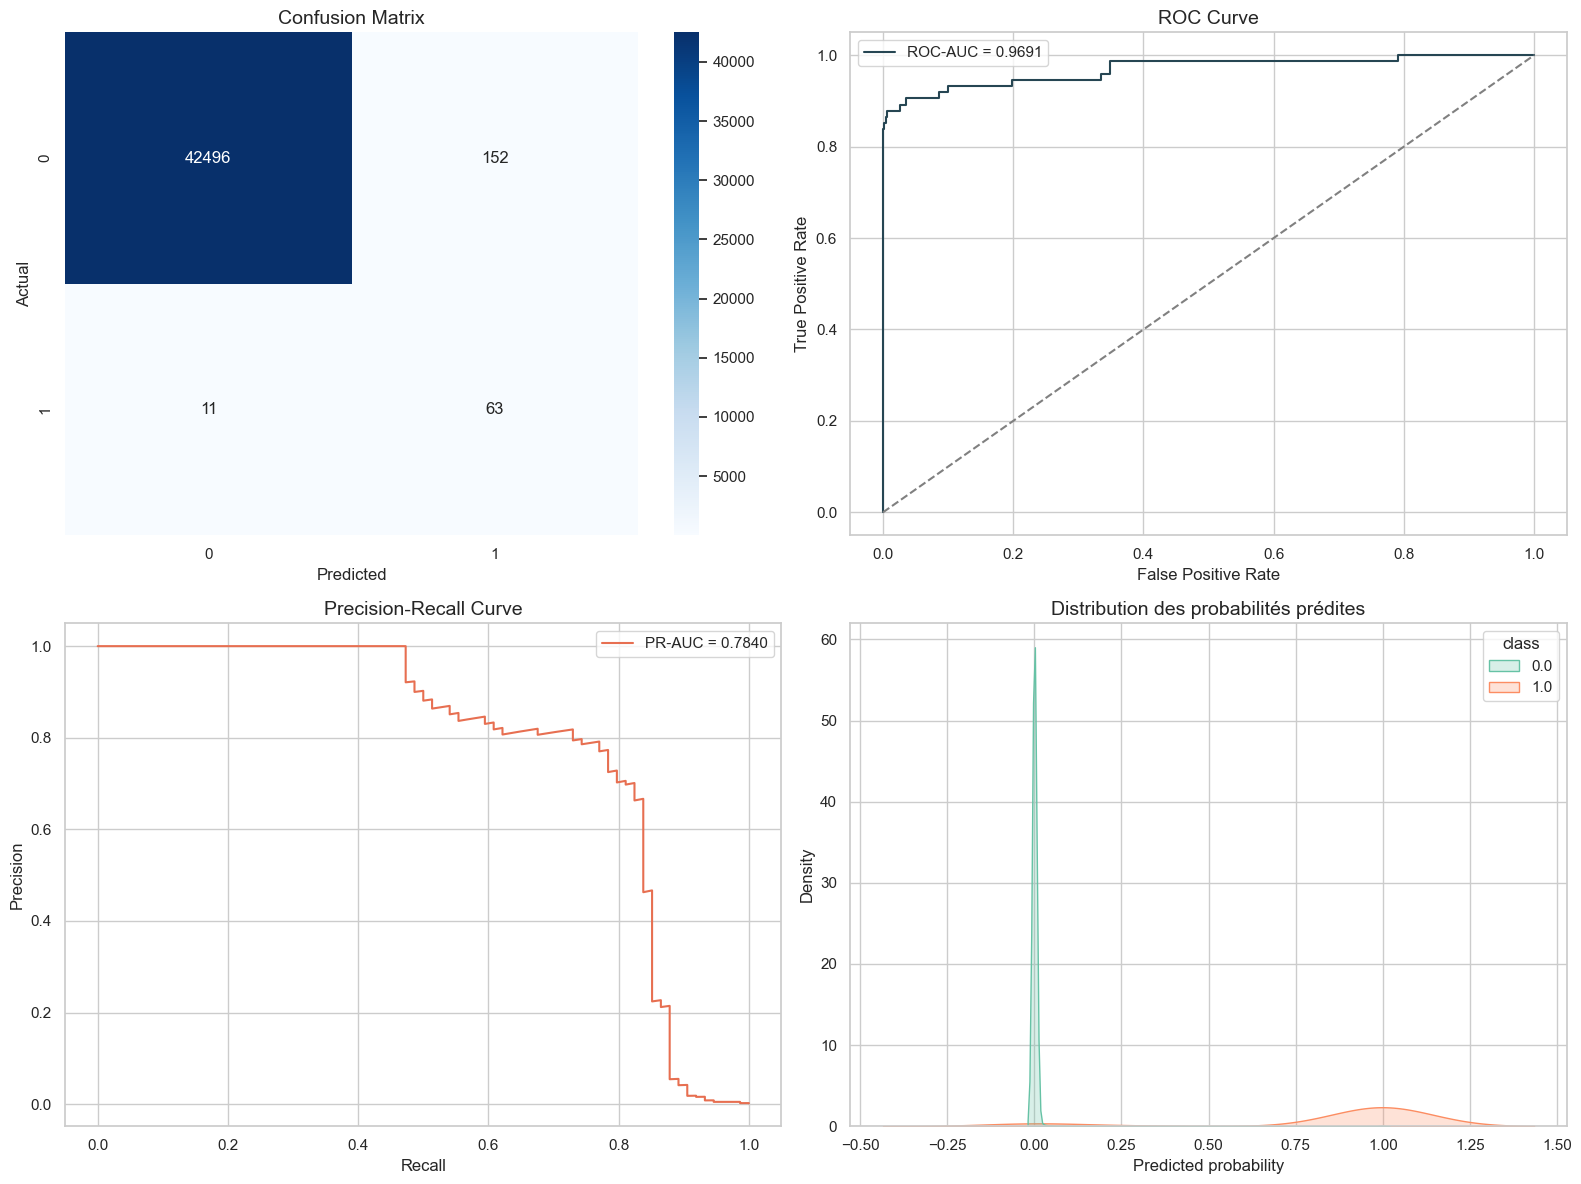

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0, 0])
axes[0, 0].set_title("Confusion Matrix")
axes[0, 0].set_xlabel("Predicted")
axes[0, 0].set_ylabel("Actual")

fpr, tpr, _ = roc_curve(y_test_true, y_test_prob)
roc_auc = roc_auc_score(y_test_true, y_test_prob)
axes[0, 1].plot(fpr, tpr, label=f"ROC-AUC = {roc_auc:.4f}", color="#264653")
axes[0, 1].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[0, 1].set_title("ROC Curve")
axes[0, 1].set_xlabel("False Positive Rate")
axes[0, 1].set_ylabel("True Positive Rate")
axes[0, 1].legend()

precision, recall, _ = precision_recall_curve(y_test_true, y_test_prob)
pr_auc = average_precision_score(y_test_true, y_test_prob)
axes[1, 0].plot(recall, precision, label=f"PR-AUC = {pr_auc:.4f}", color="#e76f51")
axes[1, 0].set_title("Precision-Recall Curve")
axes[1, 0].set_xlabel("Recall")
axes[1, 0].set_ylabel("Precision")
axes[1, 0].legend()

score_df = pd.DataFrame({"score": y_test_prob, "class": y_test_true})
sns.kdeplot(data=score_df, x="score", hue="class", common_norm=False, fill=True, ax=axes[1, 1], palette="Set2")
axes[1, 1].set_title("Distribution des probabilités prédites")
axes[1, 1].set_xlabel("Predicted probability")
axes[1, 1].set_ylabel("Density")

plt.tight_layout()

print("Final test ROC-AUC:", roc_auc)
print("Final test PR-AUC:", pr_auc)
